# Does the path beat the sign

The trend signal is the sign of the trailing return, two prices L weeks apart. It throws away the path between them. A steady climb and a spike that round-tripped to the same place read identically.

Two questions follow, kept separate. Does a breakout, a new L-week high, beat the return sign as the direction rule. And does the cleanliness of the path predict continuation, tested as a signal and not a position size, by sorting trends into clean and choppy and reading each on the plain sign alone. Sizing is held fixed throughout, inverse volatility on $10M coins, so only the signal changes.

## Setup

Load the panel and the shared per coin book, sized for equal risk on \$10M coins with the provisional costs. Then the breakout and the efficiency ratio, all from past weeks only.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qp_research import costs, panel, plot
from qp_research.book import Book, inverse_vol
from qp_research.cv import halves
from qp_research.plot import BLUE, ORANGE, GREY
from signals import sharpe

warnings.filterwarnings('ignore')
plot.style()

p = panel.load()
b = Book(p, costs.Provisional())
W, R, LIQ, VOL, F = p.returns, b.R, p.liquidity, p.vol, p.funding
sized = lambda sig, floor=1e7: inverse_vol(p, sig, floor)

def book(sig):
    net = b.run(sized(sig.shift(1))).net
    tr = halves(net.index)
    return sharpe(net), sharpe(net[~tr])

LOOKBACKS = [1, 2, 4, 8, 12]
level = W.cumsum()
sign_by_L = {L: np.sign(W.rolling(L, min_periods=L).sum()) for L in LOOKBACKS}
er_by_L = {L: W.rolling(L, min_periods=L).sum().abs() / W.abs().rolling(L, min_periods=L).sum() for L in LOOKBACKS}
print(f'panel {W.shape}  {W.index.min().date()} .. {W.index.max().date()}')

panel (349, 681)  2020-01-05 .. 2026-09-06


## Breakout against the sign

Two direction rules across the lookback grid, unit exposure, sized only by volatility. The plain sign, long if the trailing return is positive. And a Donchian breakout, long at a new L-week high, short at a new low. Net Sharpe, all weeks and unseen.

In [2]:
d_all, d_un = {}, {}
for L in LOOKBACKS:
    brk = pd.DataFrame(0.0, index=W.index, columns=W.columns) \
        .mask(level >= level.rolling(L, min_periods=L).max(), 1.0) \
        .mask(level <= level.rolling(L, min_periods=L).min(), -1.0)
    sa, su = book(sign_by_L[L]); ba, bu = book(brk)
    d_all[L] = {'plain sign': sa, 'donchian break': ba}
    d_un[L] = {'plain sign': su, 'donchian break': bu}
dir_all = pd.DataFrame(d_all).T; dir_un = pd.DataFrame(d_un).T
dir_all.index.name = dir_un.index.name = 'L'
print('net Sharpe, all weeks'); print(dir_all.round(2))
print(); print('net Sharpe, unseen'); print(dir_un.round(2))

net Sharpe, all weeks
    plain sign  donchian break
L                             
1         0.57           -0.60
2         0.43            0.57
4         0.85            0.39
8         0.55            0.71
12        0.44            0.55

net Sharpe, unseen
    plain sign  donchian break
L                             
1         0.26           -0.02
2         0.25            0.26
4         0.55            0.11
8         0.24            0.23
12        0.12            0.23


The breakout does not beat the sign at the lookback that pays. At 4 weeks it makes 0.39 against 0.85, and 0.11 against 0.55 in the later weeks. A weekly new high on a thin alt is as often the top as the start. It draws level only at 8 weeks, 0.71 against 0.55, where the plain signal is already weak.

## Does cleanliness predict continuation

Sort each week's trends into thirds by their efficiency ratio, the net move over the sum of the weekly moves, a clean straight trend near 1 and a choppy one near 0. Run the plain sign inside each third, same sizing. If clean trends continue better, the high third earns more than the low. This asks whether the path is signal, before any question of sizing on it. The one-week lookback is dropped, its efficiency ratio is always one.

In [3]:
elig_base = (LIQ >= 1e7) & VOL.notna() & (VOL > 0)
ER_LOOKBACKS = [2, 4, 8, 12]
e_all, e_un = {}, {}
for L in ER_LOOKBACKS:
    sign, er = sign_by_L[L], er_by_L[L]
    elig = elig_base & sign.notna() & er.notna()
    err = er.where(elig)
    low = err.le(err.quantile(1 / 3, axis=1), axis=0) & elig
    high = err.ge(err.quantile(2 / 3, axis=1), axis=0) & elig
    mid = elig & ~low & ~high
    a, lo, mi, hi = book(sign), book(sign.where(low)), book(sign.where(mid)), book(sign.where(high))
    e_all[L] = {'all names': a[0], 'ER low': lo[0], 'ER mid': mi[0], 'ER high': hi[0]}
    e_un[L] = {'all names': a[1], 'ER low': lo[1], 'ER mid': mi[1], 'ER high': hi[1]}
era = pd.DataFrame(e_all).T; eru = pd.DataFrame(e_un).T
era.index.name = eru.index.name = 'L'
print('net Sharpe by cleanliness third, all weeks'); print(era.round(2))
print(); print('net Sharpe by cleanliness third, unseen'); print(eru.round(2))

net Sharpe by cleanliness third, all weeks
    all names  ER low  ER mid  ER high
L                                     
2        0.43    0.27    0.45     0.35
4        0.85    0.77    0.72     0.77
8        0.55    0.37    0.50     0.61
12       0.44    0.13    0.42     0.58

net Sharpe by cleanliness third, unseen
    all names  ER low  ER mid  ER high
L                                     
2        0.25   -0.08    0.35     0.41
4        0.55    0.62    0.34     0.48
8        0.24    0.09    0.06     0.28
12       0.12   -0.02   -0.17     0.29


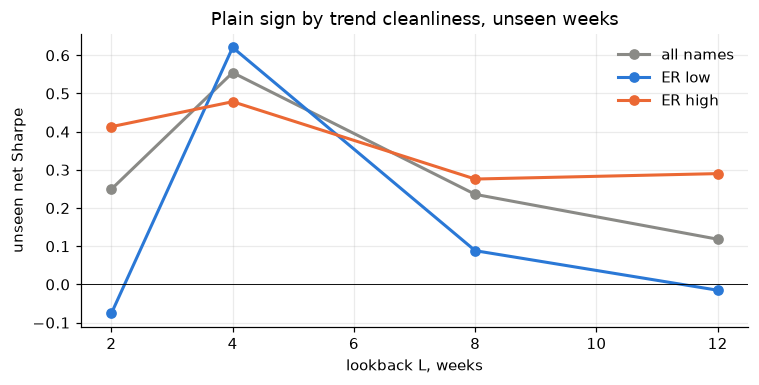

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for n, c in [('all names', GREY), ('ER low', BLUE), ('ER high', ORANGE)]:
    ax.plot(ER_LOOKBACKS, [eru.loc[L, n] for L in ER_LOOKBACKS], marker='o', color=c, label=n)
ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('lookback L, weeks'); ax.set_ylabel('unseen net Sharpe')
ax.set_title('Plain sign by trend cleanliness, unseen weeks')
ax.legend(frameon=False); plt.tight_layout(); plt.show()

At 4 weeks cleanliness carries no signal. The clean and choppy thirds continue the same, 0.77 each, and in the later weeks the choppy third even leads, 0.62 against 0.48. A clean 4-week trend is no more likely to persist than a ragged one.

It only separates at the long lookbacks. At 8 weeks the clean third makes 0.61 against 0.37, at 12 weeks 0.58 against 0.13, and it holds in the later weeks, 0.28 and 0.29 against 0.09 and below zero. A choppy long trend is mostly noise, a clean one a real move, and at 12 weeks the sign alone cannot tell them apart.

## Verdict

The path is not signal where trend pays. At 4 weeks the sign of two endpoints is the whole signal, the breakout is worse and cleanliness does not separate clean from choppy. Tested flat.

Cleanliness is real signal only at 8 and 12 weeks, where the raw sign is weak. It marks a genuine move from a ragged one, but the books it lifts stay below the 4-week sign, so it recovers a worse base rather than beating the best one.